# 6 - Multivariable Regression

Fit `life_expectancy ~ income + education + poverty + native_american + age + log_pop_density` and compare to the single-variable results.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
df = pd.read_csv('data/merged_df.csv', dtype={'fips': str})
df['log_pop_density'] = np.log10(df['pop_density'])
df = df.dropna(
    subset=['life_expectancy', 'median_hh_income', 'pct_bachelors_plus',
            'pct_poverty', 'pct_native_american', 'median_age', 'log_pop_density']
)
print('n =', len(df))

n = 3062


### Three nested models

In [2]:
socioecon = ['median_hh_income', 'pct_bachelors_plus', 'pct_poverty']
demo      = ['pct_native_american', 'median_age', 'log_pop_density']
all_p     = socioecon + demo
y = df['life_expectancy']

m_socio = sm.OLS(y, sm.add_constant(df[socioecon])).fit()
m_demo  = sm.OLS(y, sm.add_constant(df[demo])).fit()
m_full  = sm.OLS(y, sm.add_constant(df[all_p])).fit()

summary = pd.DataFrame({
    'model':  ['Socioeconomic only (3)', 'Demographic only (3)', 'Full (6)'],
    'R2':     [round(m_socio.rsquared, 3),     round(m_demo.rsquared, 3),     round(m_full.rsquared, 3)],
    'adj_R2': [round(m_socio.rsquared_adj, 3), round(m_demo.rsquared_adj, 3), round(m_full.rsquared_adj, 3)],
    'AIC':    [round(m_socio.aic, 1),          round(m_demo.aic, 1),          round(m_full.aic, 1)],
})
summary

,model,R2,adj_R2,AIC
0,Socioeconomic only (3),0.578,0.577,13610.6
1,Demographic only (3),0.093,0.092,15951.3
2,Full (6),0.650,0.649,13040.0


### Full model coefficients

In [3]:
import pandas as pd

coef_table = pd.DataFrame({
    'coef':    m_full.params.round(4),
    'std_err': m_full.bse.round(4),
    't':       m_full.tvalues.round(2),
    'p_value': m_full.pvalues.round(4),
    'ci_low':  m_full.conf_int()[0].round(3),
    'ci_high': m_full.conf_int()[1].round(3),
})

print(f"n = {int(m_full.nobs)}")
print(f"R² = {m_full.rsquared:.3f}  |  Adj R² = {m_full.rsquared_adj:.3f}")
print(f"F({int(m_full.df_model)}, {int(m_full.df_resid)}) = {m_full.fvalue:.2f}  |  p = {m_full.f_pvalue:.2e}")
print()
print(coef_table)

n = 3062
R² = 0.650  |  Adj R² = 0.649
F(6, 3055) = 945.80  |  p = 0.00e+00

                        coef  std_err       t  p_value  ci_low  ci_high
const                72.8124   0.5550  131.20   0.0000  71.724   73.901
median_hh_income      0.0001   0.0000   11.42   0.0000   0.000    0.000
pct_bachelors_plus    0.1463   0.0055   26.40   0.0000   0.135    0.157
pct_poverty          -0.1564   0.0105  -14.90   0.0000  -0.177   -0.136
pct_native_american  -0.1006   0.0056  -17.89   0.0000  -0.112   -0.090
median_age            0.0205   0.0078    2.64   0.0083   0.005    0.036
log_pop_density      -1.2851   0.0620  -20.74   0.0000  -1.407   -1.164


### Single vs. multivariable significance - the key plot

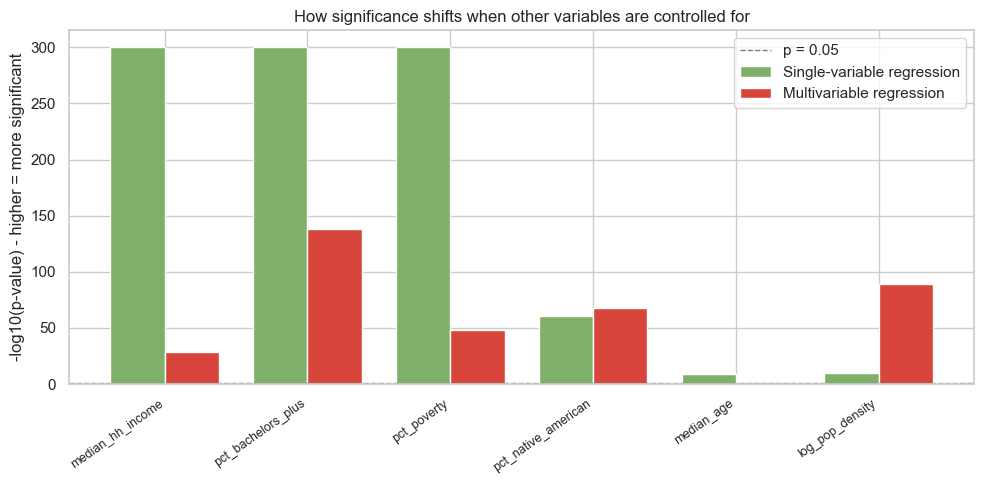

In [4]:
single_p = {p: sm.OLS(y, sm.add_constant(df[p])).fit().pvalues[p] for p in all_p}
multi_p  = {p: m_full.pvalues[p] for p in all_p}

fig, ax = plt.subplots(figsize=(10, 5))
xs = np.arange(len(all_p)); w = 0.38
ax.bar(xs - w/2, [-np.log10(max(single_p[p], 1e-300)) for p in all_p], w,
       label='Single-variable regression', color='#7fb069')
ax.bar(xs + w/2, [-np.log10(max(multi_p[p], 1e-300))  for p in all_p], w,
       label='Multivariable regression',   color='#d8453b')
ax.axhline(-np.log10(0.05), color='gray', linestyle='--', linewidth=1, label='p = 0.05')
ax.set_xticks(xs); ax.set_xticklabels(all_p, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('-log10(p-value) - higher = more significant')
ax.set_title('How significance shifts when other variables are controlled for')
ax.legend()
plt.tight_layout(); plt.show()

### Coefficient comparison: single-variable vs. multivariable slopes

In [5]:
single_b = {p: sm.OLS(y, sm.add_constant(df[p])).fit().params[p] for p in all_p}
multi_b  = {p: m_full.params[p] for p in all_p}

comparison = pd.DataFrame({
    'predictor':       all_p,
    'single_var_coef': [round(single_b[p], 4) for p in all_p],
    'multivar_coef':   [round(multi_b[p],  4) for p in all_p],
    'shrinkage':       [f'{(multi_b[p]/single_b[p]*100):.0f}%' if single_b[p] != 0 else 'n/a' for p in all_p],
})
comparison

,predictor,single_var_coef,multivar_coef,shrinkage
0,median_hh_income,0.0001,0.0001,38%
1,pct_bachelors_plus,0.2098,0.1463,70%
2,pct_poverty,-0.3869,-0.1564,40%
3,pct_native_american,-0.1351,-0.1006,75%
4,median_age,0.0721,0.0205,29%
5,log_pop_density,0.5292,-1.2851,-243%


### R-squared stepwise

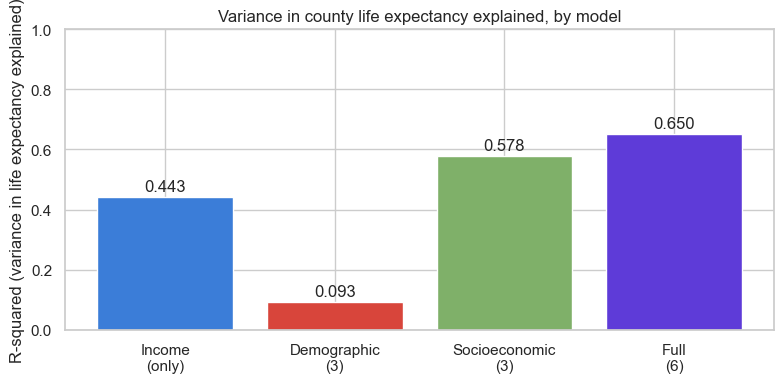

In [6]:
m_inc = sm.OLS(y, sm.add_constant(df['median_hh_income'])).fit()

fig, ax = plt.subplots(figsize=(8, 4))
labels = ['Income\n(only)', 'Demographic\n(3)', 'Socioeconomic\n(3)', 'Full\n(6)']
vals = [m_inc.rsquared, m_demo.rsquared, m_socio.rsquared, m_full.rsquared]
colors = ['#3b7dd8', '#d8453b', '#7fb069', '#5e3bd8']
bars = ax.bar(labels, vals, color=colors, edgecolor='white')
ax.set_ylabel('R-squared (variance in life expectancy explained)')
ax.set_ylim(0, 1)
ax.set_title('Variance in county life expectancy explained, by model')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.3f}', ha='center')
plt.tight_layout(); plt.show()